<a href="https://colab.research.google.com/github/sangpm2005/TTNT/blob/main/TTNT_Tuan05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

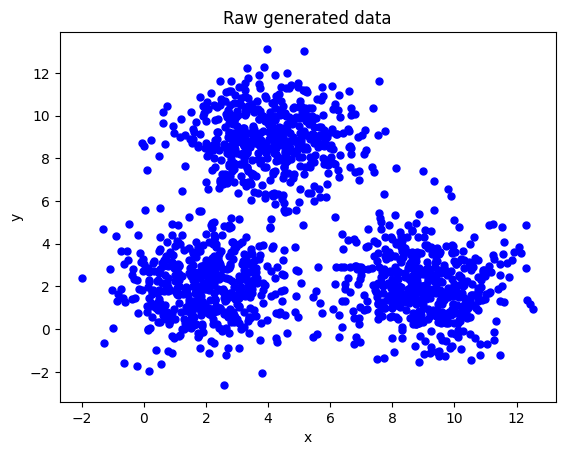

Initial centers:
[[7.67891852 2.66087631]
 [3.67724664 8.25640858]
 [9.40779479 3.56256691]]


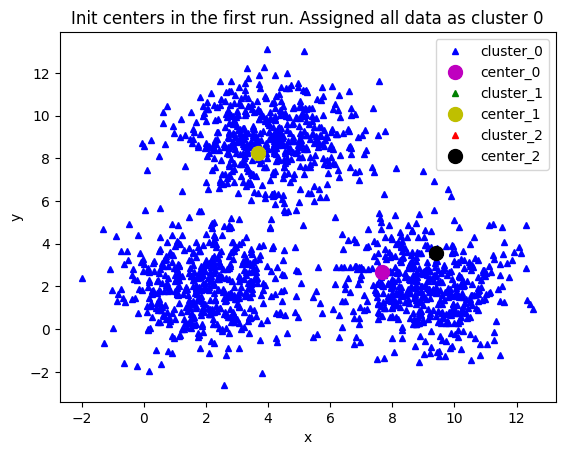

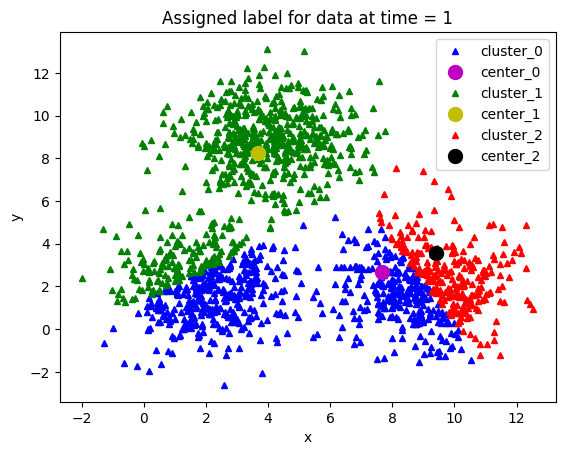

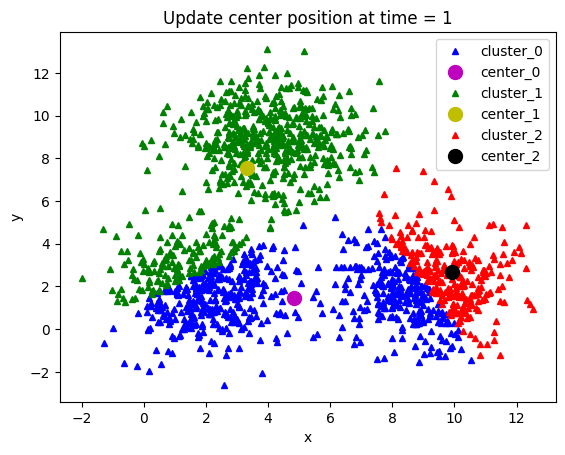

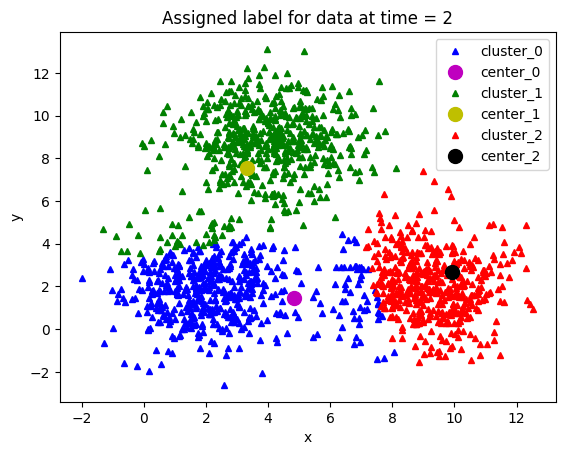

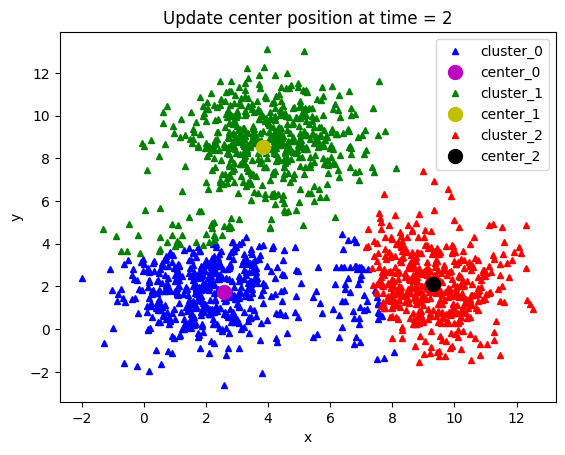

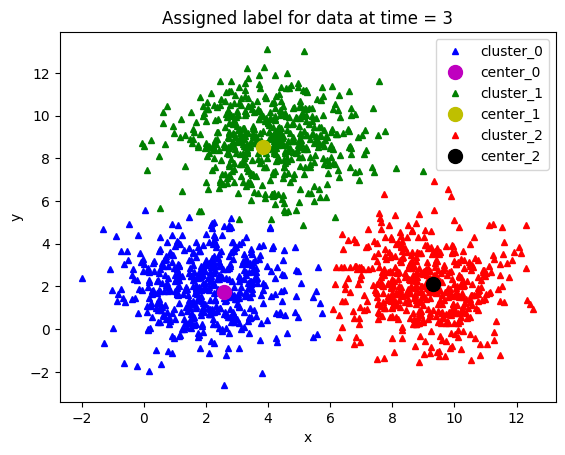

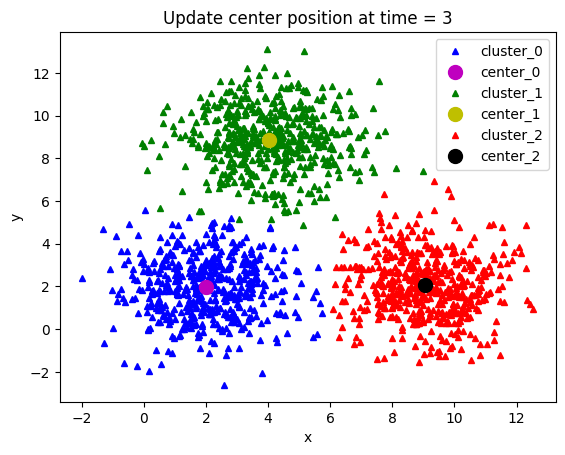

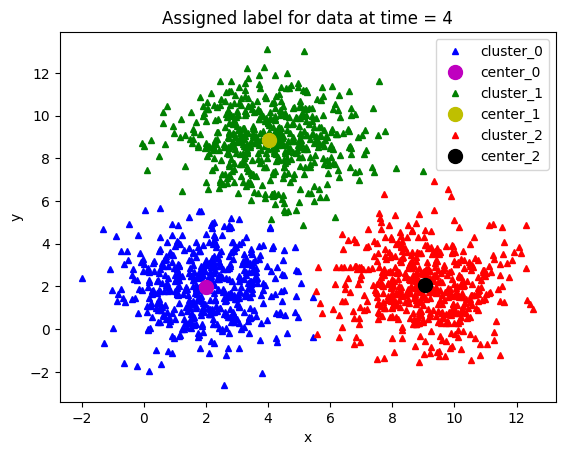

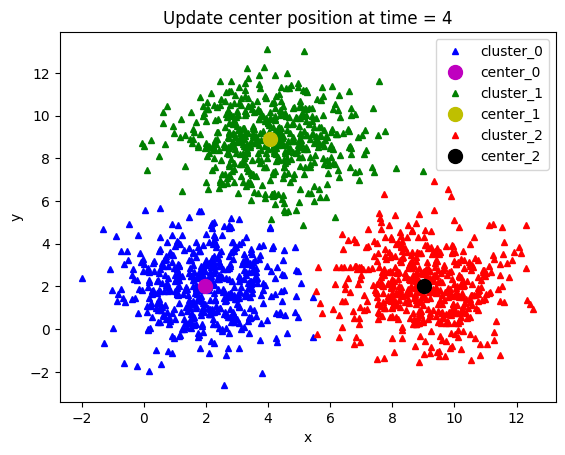

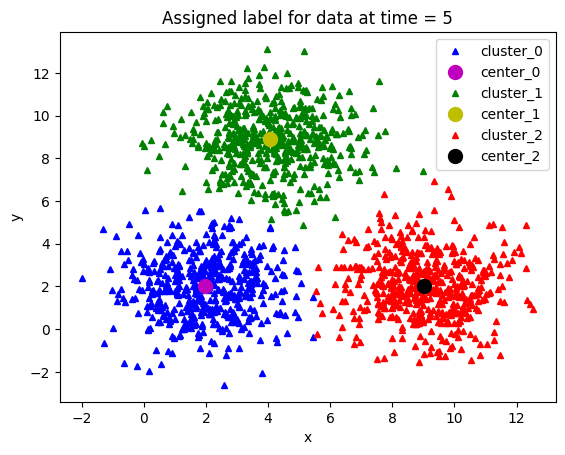

Done! Kmeans has converged after 4 times
Final centers:
[[1.96989555 1.99762835]
 [4.05750559 8.88628622]
 [9.01847918 2.03726377]]


In [ ]:
# K-Means

# =========================
# STEP 1: Import libraries
# =========================

import numpy as np                  # Tính toán số học
import matplotlib.pyplot as plt     # Vẽ đồ thị
from scipy.spatial.distance import cdist  # Tính khoảng cách giữa các điểm

# =========================
# STEP 2: Create dataset
# =========================

means = [[2, 2], [9, 2], [4, 9]]     # 3 tâm cụm thực
cov = [[2, 0], [0, 2]]

n_samples = 500
n_cluster = 3

X0 = np.random.multivariate_normal(means[0], cov, n_samples)
X1 = np.random.multivariate_normal(means[1], cov, n_samples)
X2 = np.random.multivariate_normal(means[2], cov, n_samples)

# Gộp toàn bộ dữ liệu lại
X = np.concatenate((X0, X1, X2), axis=0)

# =========================
# STEP 3: Plot raw dataset
# =========================

plt.xlabel('x')
plt.ylabel('y')
plt.plot(X[:, 0], X[:, 1], 'bo', markersize=5)
plt.title("Raw generated data")
plt.show()

# =========================
# STEP 4: Init centers
# =========================

def kmeans_init_centers(X, n_cluster):
    # Random k điểm không trùng nhau làm tâm cụm
    return X[np.random.choice(X.shape[0], n_cluster, replace=False)]

# =========================
# STEP 5: Predict labels
# =========================

def kmeans_predict_labels(X, centers):
    D = cdist(X, centers)         # Tính khoảng cách
    return np.argmin(D, axis=1)  # Gán nhãn theo tâm gần nhất

# =========================
# STEP 6: Update centers
# =========================

def kmeans_update_centers(X, labels, n_cluster):
    centers = np.zeros((n_cluster, X.shape[1]))

    for k in range(n_cluster):
        # Lấy các điểm của cụm k
        Xk = X[labels == k, :]
        # Lấy trung bình để cập nhật tâm
        centers[k, :] = np.mean(Xk, axis=0)

    return centers

# =========================
# STEP 7: Check converge
# =========================

def kmeans_has_converged(centers, new_centers):
    # Kiểm tra 2 tập tâm có giống nhau không
    return (set([tuple(a) for a in centers]) ==
            set([tuple(a) for a in new_centers]))

# =========================
# STEP 8: Visualization
# =========================

def kmeans_visualize(X, centers, labels, n_cluster, title):

    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(title)

    plt_colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k', 'w']

    for i in range(n_cluster):
        data = X[labels == i]

        # Vẽ dữ liệu trong cụm
        plt.plot(
            data[:, 0],
            data[:, 1],
            plt_colors[i] + '^',
            markersize=4,
            label='cluster_' + str(i)
        )

        # Vẽ tâm cụm
        plt.plot(
            centers[i][0],
            centers[i][1],
            plt_colors[i + 4] + 'o',
            markersize=10,
            label='center_' + str(i)
        )

    plt.legend()
    plt.show()

# =========================
# STEP 9: K-Means Algorithm
# =========================

def kmeans(init_centers, init_labels, X, n_cluster):

    centers = init_centers
    labels = init_labels

    times = 0

    while True:

        # Gán nhãn lại
        labels = kmeans_predict_labels(X, centers)

        kmeans_visualize(
            X,
            centers,
            labels,
            n_cluster,
            'Assigned label for data at time = ' + str(times + 1)
        )

        # Cập nhật tâm mới
        new_centers = kmeans_update_centers(X, labels, n_cluster)

        # Kiểm tra hội tụ
        if kmeans_has_converged(centers, new_centers):
            break

        centers = new_centers

        kmeans_visualize(
            X,
            centers,
            labels,
            n_cluster,
            'Update center position at time = ' + str(times + 1)
        )

        times += 1

    return centers, labels, times

# =========================
# STEP 10: Run K-Means
# =========================

init_centers = kmeans_init_centers(X, n_cluster)
print("Initial centers:")
print(init_centers)

# Gán toàn bộ nhãn ban đầu = 0
init_labels = np.zeros(X.shape[0])

# Vẽ hình khởi tạo
kmeans_visualize(
    X,
    init_centers,
    init_labels,
    n_cluster,
    'Init centers in the first run. Assigned all data as cluster 0'
)

# Chạy thuật toán
centers, labels, times = kmeans(init_centers, init_labels, X, n_cluster)

print('Done! Kmeans has converged after', times, 'times')
print("Final centers:")
print(centers)


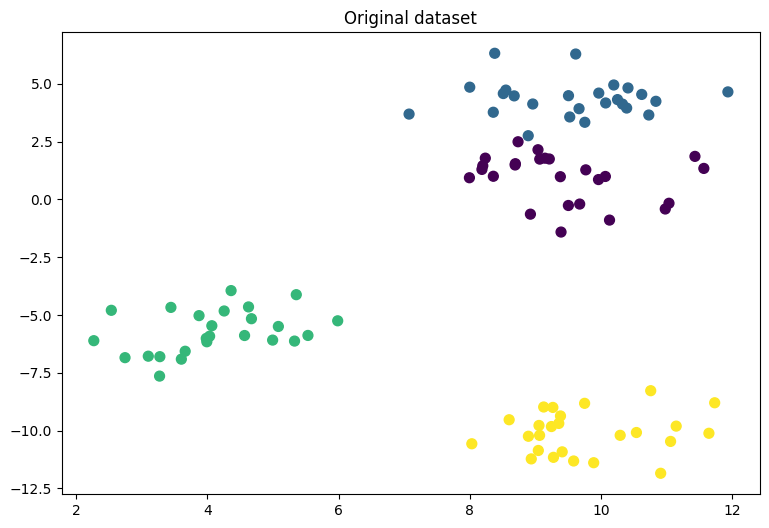

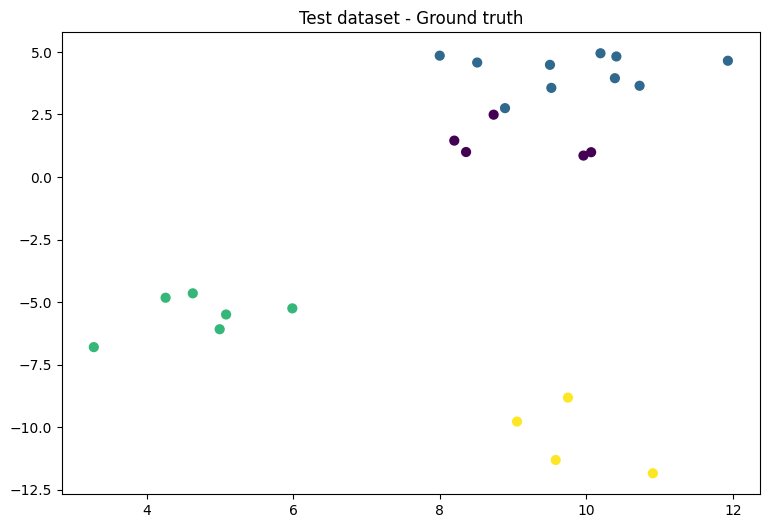

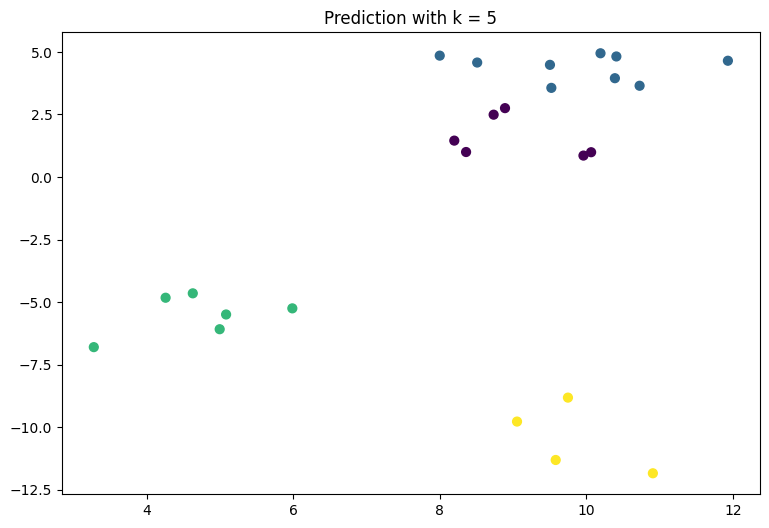

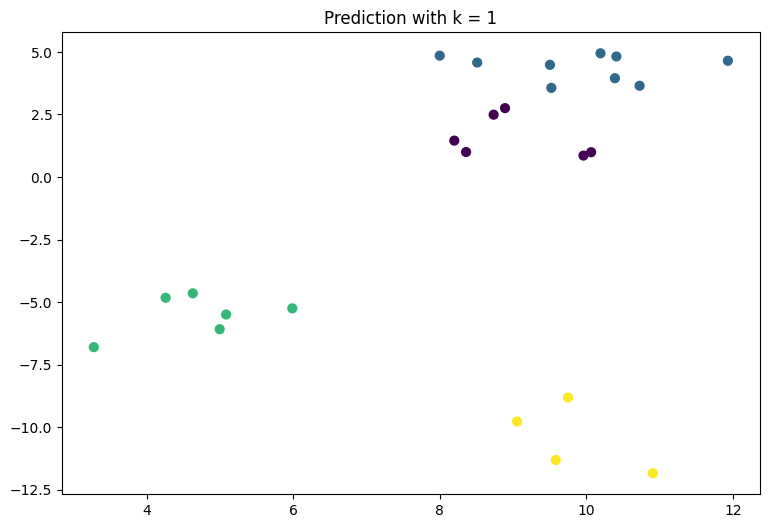

Best k found = {'n_neighbors': np.int64(2)}
Predicted class for point (1,3): [0]


In [ ]:
# K-NN

# =====================================
# STEP 1: Import các thư viện cần thiết
# =====================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt                   # Data visualization

from sklearn.datasets import make_blobs            # Tạo dữ liệu synthetic
from sklearn.neighbors import KNeighborsClassifier # kNN model
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV  # Tìm k tối ưu

# =====================================
# STEP 2: Tạo bộ dữ liệu
# =====================================

X, y = make_blobs(
    n_samples=100,
    n_features=2,
    centers=4,
    cluster_std=1,
    random_state=4
)

# =====================================
# STEP 3: Vẽ dữ liệu gốc
# =====================================

plt.figure(figsize=(9,6))
plt.scatter(X[:,0], X[:,1], c=y, marker='o', s=50)
plt.title("Original dataset")
plt.show()

# =====================================
# STEP 4: Chia train/test 75% - 25%
# =====================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=0
)

plt.figure(figsize=(9,6))
plt.scatter(X_test[:,0], X_test[:,1], c=y_test, marker='o', s=40)
plt.title("Test dataset - Ground truth")
plt.show()

# =====================================
# STEP 5: kNN với k = 5
# =====================================

knn5 = KNeighborsClassifier(5)
knn5.fit(X_train, y_train)

y_pred_5 = knn5.predict(X_test)

plt.figure(figsize=(9,6))
plt.scatter(X_test[:,0], X_test[:,1], c=y_pred_5, marker='o', s=40)
plt.title("Prediction with k = 5")
plt.show()

# =====================================
# STEP 6: kNN với k = 1
# =====================================

knn1 = KNeighborsClassifier(1)
knn1.fit(X_train, y_train)

y_pred_1 = knn1.predict(X_test)

plt.figure(figsize=(9,6))
plt.scatter(X_test[:,0], X_test[:,1], c=y_pred_1, marker='o', s=40)
plt.title("Prediction with k = 1")
plt.show()

# =====================================
# STEP 7: Dùng GridSearchCV tìm k tối ưu
# =====================================

knn_grid = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid={
        'n_neighbors': np.arange(1, 10)
    },
    cv=5
)

knn_grid.fit(X, y)

print("Best k found =", knn_grid.best_params_)

best_k = knn_grid.best_params_['n_neighbors']

# =====================================
# STEP 8: Viết hàm k-NN thủ công
# =====================================

def KNN(X_train, X_test, y_train, k):

    num_test = X_test.shape[0]
    num_train = X_train.shape[0]

    # Ma trận khoảng cách
    y_pred = np.zeros((num_test, num_train))

    # Tính khoảng cách Euclidean
    for i in range(num_test):
        for j in range(num_train):
            y_pred[i, j] = np.sqrt(
                np.sum(np.power(X_test[i,:] - X_train[j,:], 2))
            )

    results = []

    # Phân loại dựa trên top k nearest neighbors
    for i in range(len(y_pred)):

        zipped = zip(y_pred[i,:], y_train)
        res = sorted(zipped, key=lambda x: x[0])

        results_topk = res[:k]

        classes = {}

        for _, j in results_topk:
            j = int(j)
            if j not in classes:
                classes[j] = 1
            else:
                classes[j] = classes[j] + 1

        # Class có tần suất cao nhất
        results.append(max(classes, key=classes.get))

    return np.array(results)

# =====================================
# STEP 9: Test hàm KNN thủ công
# =====================================

# Tạo lại dữ liệu nhiều hơn
(X, y) = make_blobs(
    n_samples=500,
    n_features=2,
    centers=4,
    cluster_std=1,
    random_state=4
)

# Điểm cần dự đoán
X_test = np.array([(1, 3)])

# Dự đoán với best k tìm được
results = KNN(X, X_test, y, best_k)

print("Predicted class for point (1,3):", results)

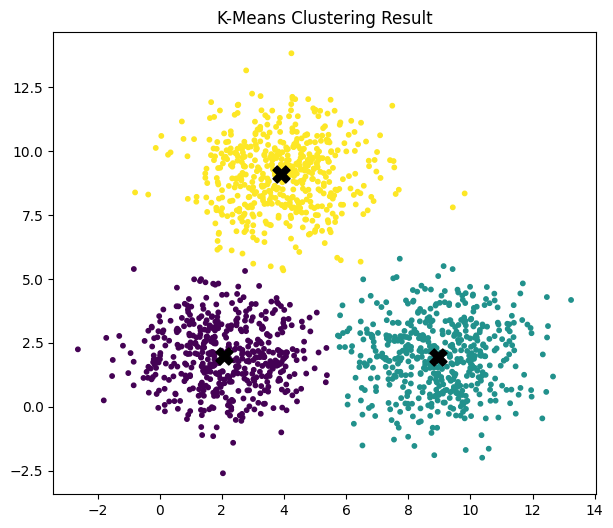

In [ ]:
# ========================
# K-MEANS DEMO APPLICATION
# ========================

import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

# ---------- Tao dataset ----------
means = [[2,2],[9,2],[4,9]]
cov = [[2,0],[0,2]]
n_samples = 500
n_cluster = 3

X = np.concatenate((
    np.random.multivariate_normal(means[0], cov, n_samples),
    np.random.multivariate_normal(means[1], cov, n_samples),
    np.random.multivariate_normal(means[2], cov, n_samples)
), axis=0)

# ---------- Khoi tao centers ----------
def kmeans_init_centers(X, k):
    return X[np.random.choice(X.shape[0], k, replace=False)]

# ---------- Gan nhan ----------
def kmeans_predict_labels(X, centers):
    return np.argmin(cdist(X, centers), axis=1)

# ---------- Cap nhat center ----------
def kmeans_update_centers(X, labels, k):
    centers = np.zeros((k, X.shape[1]))
    for i in range(k):
        centers[i] = np.mean(X[labels == i], axis=0)
    return centers

# ---------- Hoi tu ----------
def kmeans_has_converged(old, new):
    return set(map(tuple, old)) == set(map(tuple, new))

# ---------- Ve ----------
def plot_kmeans(X, centers, labels, title):
    plt.figure(figsize=(7,6))
    plt.scatter(X[:,0], X[:,1], c=labels, s=10)
    plt.scatter(centers[:,0], centers[:,1], c='black', s=150, marker='X')
    plt.title(title)
    plt.show()

# ---------- Chay KMeans ----------
def run_kmeans(X, k):

    centers = kmeans_init_centers(X,k)
    while True:
        labels = kmeans_predict_labels(X, centers)
        new_centers = kmeans_update_centers(X, labels, k)
        if kmeans_has_converged(centers, new_centers):
            break
        centers = new_centers

    plot_kmeans(X, centers, labels, "K-Means Clustering Result")

# ---------- Run ----------
run_kmeans(X, n_cluster)


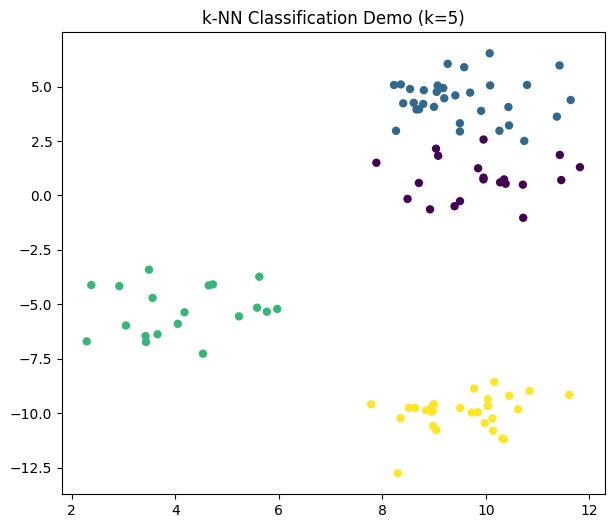

In [ ]:
# ======================
#   K-NN DEMO APP
# ======================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

# ----------- Tao dataset -----------
X, y = make_blobs(
    n_samples=400,
    centers=4,
    n_features=2,
    cluster_std=1,
    random_state=4
)

# ----------- Train / Test ----------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=0
)

# ----------- Training kNN ----------
k = 5
knn = KNeighborsClassifier(k)
knn.fit(X_train, y_train)

# ----------- Prediction ----------
y_pred = knn.predict(X_test)

# ----------- Visualization ----------
plt.figure(figsize=(7,6))
plt.scatter(X_test[:,0], X_test[:,1], c=y_pred, s=25)
plt.title(f"k-NN Classification Demo (k={k})")
plt.show()
